In [1]:

# load cleaned Mbeya data, run auto_arima to find best (p,d,q)(P,D,Q,12)
import sys
sys.path.append("..")
import pandas as pd
from pmdarima import auto_arima

mbeya_clean = pd.read_csv("../data/processed/mbeya_clean.csv", parse_dates=["date"])
mbeya_series = mbeya_clean.set_index("date")["price"]
mbeya_series = mbeya_series.asfreq("MS")

print(f"Mbeya series: {len(mbeya_series)} months, {mbeya_series.isna().sum()} missing")

mbeya_auto = auto_arima(
    mbeya_series,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    m=12,
    seasonal=True,
    information_criterion="aic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print("\n=== Best Mbeya model ===")
print(f"Order: {mbeya_auto.order}")
print(f"Seasonal order: {mbeya_auto.seasonal_order}")
print(f"AIC: {mbeya_auto.aic():.2f}")

Mbeya series: 241 months, 0 missing
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4947.341, Time=0.68 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4934.458, Time=2.86 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4934.456, Time=5.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4945.465, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=4949.060, Time=0.97 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=4936.387, Time=10.04 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=4936.410, Time=5.20 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=4934.686, Time=3.08 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=4937.748, Time=15.63 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4932.242, Time=2.20 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4934.160, Time=5.36 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=4934.193, Time=3.67 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4932.437, Time=0.85 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4935.

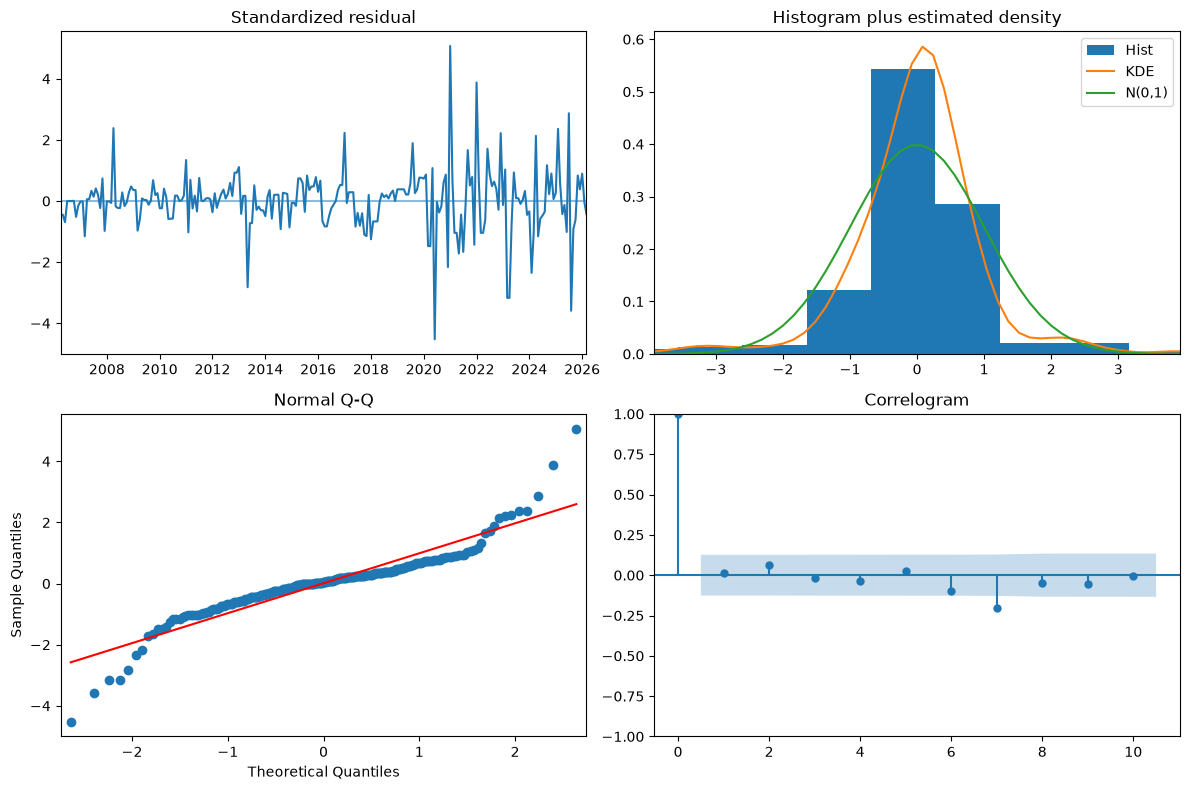

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  241
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood               -2462.946
Date:                            Mon, 22 Jun 2026   AIC                           4929.891
Time:                                    11:15:08   BIC                           4936.853
Sample:                                03-01-2006   HQIC                          4932.696
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.2661      0.038      7.005      0.000       0.192       0.341
sigma2      4.972e+07   2.01e-10   

In [2]:
# notebook: 04_model_development.ipynb
import matplotlib.pyplot as plt

# Generate diagnostic plots
mbeya_auto.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Also check the mathematical summary table for Ljung-Box test
print(mbeya_auto.summary())

In [3]:
# train/test split -- 80/20 temporal, no shuffling
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

n_test = int(len(mbeya_series) * 0.20)
n_train = len(mbeya_series) - n_test

mbeya_train = mbeya_series.iloc[:n_train]
mbeya_test = mbeya_series.iloc[n_train:]

print(f"Train: {mbeya_train.index[0].date()} to {mbeya_train.index[-1].date()} ({len(mbeya_train)} months)")
print(f"Test:  {mbeya_test.index[0].date()} to {mbeya_test.index[-1].date()} ({len(mbeya_test)} months)")

# fit on training data only, using the order auto_arima found
mbeya_model = SARIMAX(
    mbeya_train,
    order=(0, 1, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(mbeya_model.summary())

Train: 2006-03-01 to 2022-03-01 (193 months)
Test:  2022-04-01 to 2026-03-01 (48 months)
                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  193
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood               -1831.141
Date:                            Mon, 22 Jun 2026   AIC                           3666.282
Time:                                    11:22:28   BIC                           3672.667
Sample:                                03-01-2006   HQIC                          3668.871
                                     - 03-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.3966    

In [4]:
# check basic scale and variance behavior across the training period
print(mbeya_train.describe())
print("\nRolling 12-month std, sampled every 24 months:")
print(mbeya_train.rolling(12).std().iloc[::24])

count      193.000000
mean     43473.970725
std      18935.853361
min      10700.000000
25%      32000.000000
50%      40303.000000
75%      53000.000000
max      90000.000000
Name: price, dtype: float64

Rolling 12-month std, sampled every 24 months:
date
2006-03-01             NaN
2008-03-01     2741.305125
2010-03-01     3789.104196
2012-03-01     2271.956937
2014-03-01     7913.741030
2016-03-01    10266.866815
2018-03-01    14578.521284
2020-03-01    16700.353413
2022-03-01    18051.249768
Freq: 24MS, Name: price, dtype: float64


In [5]:
# log-transform the Mbeya series to stabilize variance before modeling
mbeya_log = np.log(mbeya_series)

# re-check rolling std on the log scale
mbeya_log_train = mbeya_log.iloc[:n_train]
print("Rolling 12-month std on LOG scale, sampled every 24 months:")
print(mbeya_log_train.rolling(12).std().iloc[::24])

Rolling 12-month std on LOG scale, sampled every 24 months:
date
2006-03-01         NaN
2008-03-01    0.188699
2010-03-01    0.118749
2012-03-01    0.061218
2014-03-01    0.137647
2016-03-01    0.201853
2018-03-01    0.244573
2020-03-01    0.271135
2022-03-01    0.305123
Freq: 24MS, Name: price, dtype: float64


In [6]:
# refit Mbeya model on log-transformed training data
mbeya_model_log = SARIMAX(
    mbeya_log_train,
    order=(0, 1, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(mbeya_model_log.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  193
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                  98.899
Date:                            Mon, 22 Jun 2026   AIC                           -193.797
Time:                                    11:50:04   BIC                           -187.412
Sample:                                03-01-2006   HQIC                          -191.208
                                     - 03-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.1639      0.055      2.985      0.003       0.056       0.272
sigma2         0.0195      0.001   

In [7]:
# forecast on the test set using the log model, convert back to real price scale
mbeya_forecast_log = mbeya_model_log.get_forecast(steps=len(mbeya_test))
mbeya_forecast_mean_log = mbeya_forecast_log.predicted_mean
mbeya_forecast_ci_log = mbeya_forecast_log.conf_int(alpha=0.05)

# convert log-scale forecasts back to real prices
mbeya_forecast_mean = np.exp(mbeya_forecast_mean_log)
mbeya_forecast_lower = np.exp(mbeya_forecast_ci_log.iloc[:, 0])
mbeya_forecast_upper = np.exp(mbeya_forecast_ci_log.iloc[:, 1])

actual = mbeya_test.values
pred = mbeya_forecast_mean.values

mape = np.mean(np.abs((actual - pred) / actual)) * 100
rmse = np.sqrt(np.mean((actual - pred) ** 2))
mae = np.mean(np.abs(actual - pred))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")

MAPE: 24.50%
RMSE: 18,678
MAE:  15,272


In [8]:
# proper evaluation: walk-forward 1-month-ahead and 3-month-ahead accuracy only
# this matches what the deployed system will actually do
horizons = [1, 3]

for h in horizons:
    errors = []
    for i in range(len(mbeya_test) - h + 1):
        train_end = n_train + i
        train_slice = mbeya_log.iloc[:train_end]
        
        model_h = SARIMAX(
            train_slice,
            order=(0, 1, 0),
            seasonal_order=(1, 0, 0, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        forecast_h = model_h.get_forecast(steps=h)
        pred_log = forecast_h.predicted_mean.iloc[-1]
        pred_price = np.exp(pred_log)
        
        actual_price = mbeya_series.iloc[train_end + h - 1]
        
        errors.append(abs((actual_price - pred_price) / actual_price) * 100)
    
    mape_h = np.mean(errors)
    print(f"{h}-month-ahead walk-forward MAPE: {mape_h:.2f}%  (n={len(errors)} forecasts)")

/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1-month-ahead walk-forward MAPE: 9.61%  (n=48 forecasts)


/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


3-month-ahead walk-forward MAPE: 18.87%  (n=46 forecasts)


In [9]:
# check whether error is concentrated in specific years
errors_by_month = pd.Series(
    np.abs((actual - pred) / actual) * 100,
    index=mbeya_test.index
)
print(errors_by_month.resample("YE").mean())

date
2022-12-31    14.104123
2023-12-31    11.928388
2024-12-31    46.541388
2025-12-31    24.777175
2026-12-31    16.677367
Freq: YE-DEC, dtype: float64


In [10]:
# inspect 2024 specifically -- actual vs predicted, side by side
comparison_2024 = pd.DataFrame({
    "actual": mbeya_test["2024"],
    "predicted": mbeya_forecast_mean["2024"]
})
comparison_2024["pct_error"] = (
    (comparison_2024["actual"] - comparison_2024["predicted"]) 
    / comparison_2024["actual"] * 100
)
print(comparison_2024)

              actual     predicted  pct_error
2024-01-01  80000.00  80092.079852  -0.115100
2024-02-01  65810.25  80253.535149 -21.946863
2024-03-01  51620.50  80000.000001 -54.977189
2024-04-01  60000.00  79952.976718 -33.254961
2024-05-01  50000.00  79898.726691 -59.797453
2024-06-01  48354.50  79823.903531 -65.080610
2024-07-01  45383.50  79728.833662 -75.678019
2024-08-01  43300.00  79719.215529 -84.109043
2024-09-01  51923.00  79816.950860 -53.721763
2024-10-01  53867.50  79851.360875 -48.236619
2024-11-01  60833.00  79898.726691 -31.341092
2024-12-01  61278.00  79807.209172 -30.237947


IRINGA MODEL DEVELOPMENT

In [11]:

# load cleaned Iringa data, run auto_arima with d=1 (locked in from ACF/PACF evidence)
iringa_clean = pd.read_csv("../data/processed/iringa_clean.csv", parse_dates=["date"])
iringa_series = iringa_clean.set_index("date")["price"]
iringa_series = iringa_series.asfreq("MS")

print(f"Iringa series: {len(iringa_series)} months, {iringa_series.isna().sum()} missing")

iringa_auto = auto_arima(
    iringa_series,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    m=12,
    seasonal=True,
    information_criterion="aic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

print("\n=== Best Iringa model ===")
print(f"Order: {iringa_auto.order}")
print(f"Seasonal order: {iringa_auto.seasonal_order}")
print(f"AIC: {iringa_auto.aic():.2f}")

Iringa series: 243 months, 0 missing
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4931.365, Time=38.49 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4931.414, Time=3.09 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4932.402, Time=1.26 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4929.601, Time=0.50 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4933.328, Time=1.76 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4933.321, Time=2.00 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4935.266, Time=6.39 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4929.504, Time=0.44 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=4931.392, Time=1.95 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4933.265, Time=4.25 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=4924.466, Time=0.80 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=4926.464, Time=3.06 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=4926.463, Time=3.25 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=4928.

In [12]:
# check rolling volatility on Iringa raw scale, then log scale, same as Mbeya
n_test_i = int(len(iringa_series) * 0.20)
n_train_i = len(iringa_series) - n_test_i

iringa_train = iringa_series.iloc[:n_train_i]
iringa_test = iringa_series.iloc[n_train_i:]

print(f"Train: {iringa_train.index[0].date()} to {iringa_train.index[-1].date()} ({len(iringa_train)} months)")
print(f"Test:  {iringa_test.index[0].date()} to {iringa_test.index[-1].date()} ({len(iringa_test)} months)")

print("\nRolling 12-month std, raw scale, sampled every 24 months:")
print(iringa_train.rolling(12).std().iloc[::24])

iringa_log_train = np.log(iringa_train)
print("\nRolling 12-month std, log scale, sampled every 24 months:")
print(iringa_log_train.rolling(12).std().iloc[::24])

Train: 2006-01-01 to 2022-03-01 (195 months)
Test:  2022-04-01 to 2026-03-01 (48 months)

Rolling 12-month std, raw scale, sampled every 24 months:
date
2006-01-01             NaN
2008-01-01     6050.248868
2010-01-01     2850.993995
2012-01-01     1983.477734
2014-01-01    16170.451245
2016-01-01     9443.845971
2018-01-01    26252.187052
2020-01-01    15769.644230
2022-01-01     7429.161776
Freq: 24MS, Name: price, dtype: float64

Rolling 12-month std, log scale, sampled every 24 months:
date
2006-01-01         NaN
2008-01-01    0.340380
2010-01-01    0.089494
2012-01-01    0.060603
2014-01-01    0.302031
2016-01-01    0.225645
2018-01-01    0.416977
2020-01-01    0.289051
2022-01-01    0.175412
Freq: 24MS, Name: price, dtype: float64


In [13]:
# fit Iringa SARIMAX on RAW scale first (no log), check for the same degenerate sigma2 symptom
iringa_model_raw = SARIMAX(
    iringa_train,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(iringa_model_raw.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  195
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -1926.156
Date:                Mon, 22 Jun 2026   AIC                           3858.312
Time:                        12:35:03   BIC                           3868.085
Sample:                    01-01-2006   HQIC                          3862.270
                         - 03-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2242      0.052      4.275      0.000       0.121       0.327
ar.L2          0.0816      0.060      1.364      0.173      -0.036       0.199
sigma2      3.029e+07   1.48e-09   2.05e+16      0.0

In [14]:
# refit Iringa on log scale, same order
iringa_log = np.log(iringa_series)
iringa_log_train = iringa_log.iloc[:n_train_i]

iringa_model_log = SARIMAX(
    iringa_log_train,
    order=(2, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(iringa_model_log.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  195
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 124.713
Date:                Mon, 22 Jun 2026   AIC                           -243.426
Time:                        12:43:21   BIC                           -233.654
Sample:                    01-01-2006   HQIC                          -239.468
                         - 03-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2106      0.059      3.591      0.000       0.096       0.326
ar.L2          0.0227      0.072      0.316      0.752      -0.118       0.163
sigma2         0.0160      0.001     12.852      0.0

In [15]:
# check if AR(1) alone on log scale beats AR(2) now that L2 isn't significant
iringa_model_log_ar1 = SARIMAX(
    iringa_log_train,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(f"AR(2) log-scale AIC: {iringa_model_log.aic:.2f}")
print(f"AR(1) log-scale AIC: {iringa_model_log_ar1.aic:.2f}")

AR(2) log-scale AIC: -243.43
AR(1) log-scale AIC: -243.78


In [16]:
# walk-forward 1-month and 3-month ahead MAPE for Iringa
horizons = [1, 3]

for h in horizons:
    errors = []
    for i in range(len(iringa_test) - h + 1):
        train_end = n_train_i + i
        train_slice = iringa_log.iloc[:train_end]

        model_h = SARIMAX(
            train_slice,
            order=(1, 1, 0),
            seasonal_order=(0, 0, 0, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast_h = model_h.get_forecast(steps=h)
        pred_log = forecast_h.predicted_mean.iloc[-1]
        pred_price = np.exp(pred_log)

        actual_price = iringa_series.iloc[train_end + h - 1]

        errors.append(abs((actual_price - pred_price) / actual_price) * 100)

    mape_h = np.mean(errors)
    print(f"{h}-month-ahead walk-forward MAPE: {mape_h:.2f}%  (n={len(errors)} forecasts)")

/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

1-month-ahead walk-forward MAPE: 8.14%  (n=48 forecasts)


/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/moshuly/final_maizeforecast_project/final/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum 

3-month-ahead walk-forward MAPE: 17.27%  (n=46 forecasts)


In [17]:
# quick sanity check: does increasing max iterations clear the convergence warning?
test_model = SARIMAX(
    iringa_log_train,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

print(test_model.mle_retvals)

{'fopt': np.float64(-0.6353442248459918), 'gopt': array([5.22947241e-06, 6.10257167e-04]), 'fcalls': 45, 'warnflag': 0, 'converged': True, 'iterations': 1}


In [18]:
# refit both final models on FULL log-transformed series (not just training split)
# this uses all available data up to the most recent month for the live forecast
mbeya_log_full = np.log(mbeya_series)
iringa_log_full = np.log(iringa_series)

mbeya_final = SARIMAX(
    mbeya_log_full,
    order=(0, 1, 0),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

iringa_final = SARIMAX(
    iringa_log_full,
    order=(1, 1, 0),
    seasonal_order=(0, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

print("Mbeya final model fit on", len(mbeya_log_full), "months")
print("Iringa final model fit on", len(iringa_log_full), "months")
print(f"Mbeya AIC: {mbeya_final.aic:.2f}")
print(f"Iringa AIC: {iringa_final.aic:.2f}")

Mbeya final model fit on 241 months
Iringa final model fit on 243 months
Mbeya AIC: -255.49
Iringa AIC: -315.87


In [19]:
# generate 3-month forecasts with 95% prediction intervals, both regions
# convert log-scale forecasts and intervals back to real price scale

def make_forecast_table(model, region_name, steps=3):
    forecast = model.get_forecast(steps=steps)
    mean_log = forecast.predicted_mean
    ci_log = forecast.conf_int(alpha=0.05)

    table = pd.DataFrame({
        "date": mean_log.index,
        "forecast": np.exp(mean_log.values),
        "lower_95": np.exp(ci_log.iloc[:, 0].values),
        "upper_95": np.exp(ci_log.iloc[:, 1].values)
    })
    table["region"] = region_name
    return table

mbeya_forecast_table = make_forecast_table(mbeya_final, "Mbeya")
iringa_forecast_table = make_forecast_table(iringa_final, "Iringa")

print("=== Mbeya 3-month forecast ===")
print(mbeya_forecast_table.to_string(index=False))

print("\n=== Iringa 3-month forecast ===")
print(iringa_forecast_table.to_string(index=False))

=== Mbeya 3-month forecast ===
      date     forecast     lower_95      upper_95 region
2026-04-01 67594.634762 51679.979413  88410.148390  Mbeya
2026-05-01 67097.834101 45901.353572  98082.496281  Mbeya
2026-06-01 65973.778196 41441.144059 105029.422046  Mbeya

=== Iringa 3-month forecast ===
      date     forecast     lower_95      upper_95 region
2026-04-01 72355.095310 56676.351313  92371.151213 Iringa
2026-05-01 72328.443851 49535.371859 105609.458326 Iringa
2026-06-01 72323.537267 44688.345774 117048.280758 Iringa


In [20]:
import joblib

# save fitted models
joblib.dump(mbeya_final, "../models/sarima_mbeya.pkl")
joblib.dump(iringa_final, "../models/sarima_iringa.pkl")

# save forecasts
mbeya_forecast_table.to_csv("../data/outputs/mbeya_forecast.csv", index=False)
iringa_forecast_table.to_csv("../data/outputs/iringa_forecast.csv", index=False)

# save final metrics summary for the report
import json

metrics_summary = {
    "Mbeya": {
        "order": "(0,1,0)(1,0,0,12)",
        "transform": "log",
        "mape_1month": 9.61,
        "mape_3month": 18.87,
        "aic_full_fit": float(mbeya_final.aic)
    },
    "Iringa": {
        "order": "(1,1,0)(0,0,0,12)",
        "transform": "log",
        "mape_1month": 8.14,
        "mape_3month": 17.27,
        "aic_full_fit": float(iringa_final.aic)
    }
}

with open("../data/outputs/model_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("saved: models, forecasts, metrics")

saved: models, forecasts, metrics
